# Ball Tracking with TrackNet2
Extract ball trajectories from padel videos using TrackNet2 deep learning model. Tracks ball positions frame-by-frame, applies temporal smoothing, and caches results as JSON for downstream analysis.

## Setup
Import dependencies and configure paths.

In [1]:
import json
import math
from collections import deque
from pathlib import Path
from typing import List, Optional

import cv2
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from torch import nn
from tqdm.auto import tqdm

In [2]:
PROJECT_ROOT = Path('..').resolve()
DATASET_ROOT = PROJECT_ROOT / 'dataset'
BALL_CACHE = PROJECT_ROOT / 'artifacts' / 'ball_tracking'
VIDEO_CACHE = BALL_CACHE / 'videos'
BALL_CACHE.mkdir(parents=True, exist_ok=True)
VIDEO_CACHE.mkdir(parents=True, exist_ok=True)

TRACKNET_WEIGHTS = PROJECT_ROOT / 'artifacts' / 'pretrained' / 'tracknet.pt'
FRAME_SIZE = (640, 360)
HEATMAP_SHAPE = (360, 640)


def get_videos() -> pd.DataFrame:
    """Scan dataset for all videos."""
    records = []
    for stroke_dir in sorted(DATASET_ROOT.iterdir()):
        if not stroke_dir.is_dir() or stroke_dir.name.startswith('.'):
            continue
        for vid in sorted(stroke_dir.glob('*.mp4')):
            records.append({'stroke': stroke_dir.name, 'video': vid.name})
    return pd.DataFrame(records)

manifest = get_videos()

print(f"{len(manifest)} videos | {manifest['stroke'].nunique()} strokes")
manifest.groupby('stroke').size()

188 videos | 10 strokes


stroke
Backhand           20
Backhand_Volley    42
Bandeja             8
Contrapared         3
Dropshot            1
Forehand           33
Forehand_Volley    29
Lob                21
Smash              16
Vibora             15
dtype: int64

## TrackNet Model
Load the TrackNet2 architecture and weights for ball detection.

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, pad: int = 1, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=pad, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class BallTrackerNet(nn.Module):
    def __init__(self, value_bins: int = 256):
        super().__init__()
        self.value_bins = value_bins
        self.conv1 = ConvBlock(9, 64)
        self.conv2 = ConvBlock(64, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = ConvBlock(64, 128)
        self.conv4 = ConvBlock(128, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = ConvBlock(128, 256)
        self.conv6 = ConvBlock(256, 256)
        self.conv7 = ConvBlock(256, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv8 = ConvBlock(256, 512)
        self.conv9 = ConvBlock(512, 512)
        self.conv10 = ConvBlock(512, 512)
        self.ups1 = nn.Upsample(scale_factor=2)
        self.conv11 = ConvBlock(512, 256)
        self.conv12 = ConvBlock(256, 256)
        self.conv13 = ConvBlock(256, 256)
        self.ups2 = nn.Upsample(scale_factor=2)
        self.conv14 = ConvBlock(256, 128)
        self.conv15 = ConvBlock(128, 128)
        self.ups3 = nn.Upsample(scale_factor=2)
        self.conv16 = ConvBlock(128, 64)
        self.conv17 = ConvBlock(64, 64)
        self.conv18 = ConvBlock(64, self.value_bins)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch = x.size(0)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.pool3(x)
        x = self.conv8(x)
        x = self.conv9(x)
        x = self.conv10(x)
        x = self.ups1(x)
        x = self.conv11(x)
        x = self.conv12(x)
        x = self.conv13(x)
        x = self.ups2(x)
        x = self.conv14(x)
        x = self.conv15(x)
        x = self.ups3(x)
        x = self.conv16(x)
        x = self.conv17(x)
        x = self.conv18(x)
        return x.reshape(batch, self.value_bins, -1)


class TrackNetDetector:
    def __init__(self, weight_path: Path, device: Optional[str] = None):
        if device is not None:
            self.device = device
        elif torch.cuda.is_available():
            self.device = 'cuda'
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            self.device = 'mps'
        else:
            self.device = 'cpu'
        self.model = BallTrackerNet()
        state_dict = torch.load(weight_path, map_location=self.device)
        self.model.load_state_dict(state_dict)
        self.model.to(self.device)
        self.model.eval()
        self.buffer: deque[np.ndarray] = deque(maxlen=3)

    def reset(self) -> None:
        self.buffer.clear()

    def _prepare_input(self) -> np.ndarray:
        imgs = np.concatenate(list(self.buffer), axis=2)
        imgs = imgs.astype(np.float32) / 255.0
        imgs = np.transpose(imgs, (2, 0, 1))
        return imgs[None, ...]

    def _infer_heatmap(self) -> Optional[np.ndarray]:
        if len(self.buffer) < self.buffer.maxlen:
            return None
        batch = self._prepare_input()
        with torch.no_grad():
            logits = self.model(torch.from_numpy(batch).to(self.device))
            output = logits.argmax(dim=1).view(HEATMAP_SHAPE).cpu().numpy().astype(np.float32)
        heatmap = np.clip(output / 255.0, 0.0, 1.0)
        return heatmap

    def __call__(self, frame: np.ndarray, run_inference: bool = True) -> Optional[np.ndarray]:
        resized = cv2.resize(frame, FRAME_SIZE)
        self.buffer.append(resized)
        if not run_inference:
            return None
        return self._infer_heatmap()


def heatmap_to_center(heatmap: np.ndarray) -> tuple[Optional[np.ndarray], float]:
    if heatmap is None or heatmap.size == 0:
        return None, 0.0
    y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    confidence = float(heatmap[y, x])
    return np.asarray([x, y], dtype=np.float32), confidence


def resize_point_to_original(point: np.ndarray, original_shape: tuple[int, int]) -> np.ndarray:
    h, w = original_shape
    scale_x = w / FRAME_SIZE[0]
    scale_y = h / FRAME_SIZE[1]
    return np.asarray([point[0] * scale_x, point[1] * scale_y], dtype=np.float32)


if not TRACKNET_WEIGHTS.exists():
    raise FileNotFoundError(f'TrackNet weights missing: {TRACKNET_WEIGHTS}')

detector = TrackNetDetector(TRACKNET_WEIGHTS)
print(f'Loaded TrackNet on {detector.device}')

Loaded TrackNet on mps


## Ball Tracking
Process videos frame-by-frame to detect ball positions with confidence scores.

In [4]:
def track_ball_in_video(
    video_path: Path,
    detector: TrackNetDetector,
    min_confidence: float = 0.2,
    stride: int = 1,
) -> dict:
    if not video_path.exists():
        raise FileNotFoundError(video_path)
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    frame_records: List[dict] = []
    frame_idx = 0
    detector.reset()
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None
    pbar = tqdm(total=total_frames, desc=video_path.name, leave=False)
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        should_infer = frame_idx % stride == 0
        heatmap = detector(frame, run_inference=should_infer)
        if should_infer:
            record = {'frame_idx': frame_idx, 'confidence': 0.0, 'center': None}
            if heatmap is not None:
                center, confidence = heatmap_to_center(heatmap)
                record['confidence'] = float(confidence)
                if center is not None and confidence >= min_confidence:
                    record['center'] = resize_point_to_original(center, frame.shape[:2]).tolist()
            frame_records.append(record)
        frame_idx += 1
        pbar.update(1)
    pbar.close()
    cap.release()
    payload = {
        'video': video_path.name,
        'fps': fps,
        'frames': frame_records,
        'min_confidence': min_confidence,
        'stride': stride,
    }
    return payload


# Test on one video
sample_row = manifest.iloc[0]
sample_video = DATASET_ROOT / sample_row['stroke'] / sample_row['video']
raw_track = track_ball_in_video(sample_video, detector, min_confidence=0.2)
print(f"Tracked {len(raw_track['frames'])} frames")
pd.DataFrame(raw_track['frames'])

108cfa87_IMG_6554_Backhand_f1612-1625.mp4:   0%|          | 0/17 [00:00<?, ?it/s]

Tracked 17 frames


,frame_idx,confidence,center
0,0,0.000000,None
1,1,0.000000,None
2,2,0.949020,"[483.0, 705.0]"
3,3,0.949020,"[462.0, 699.0]"
4,4,0.862745,"[438.0, 678.0]"
5,5,0.862745,"[417.0, 660.0]"
6,6,0.862745,"[393.0, 648.0]"
7,7,0.058824,None
8,8,0.000000,None
9,9,0.000000,None


## Smoothing
Apply temporal smoothing and interpolation to create consistent trajectories.

In [5]:
def smooth_track(payload: dict, window: int = 5, max_gap: int = 4) -> dict:
    frames_df = pd.DataFrame(payload['frames'])
    if frames_df.empty:
        return payload
    frames_df = frames_df.sort_values('frame_idx').reset_index(drop=True)
    frames_df['x'] = frames_df['center'].apply(lambda c: c[0] if isinstance(c, list) else np.nan)
    frames_df['y'] = frames_df['center'].apply(lambda c: c[1] if isinstance(c, list) else np.nan)
    frames_df[['x', 'y']] = (
        frames_df[['x', 'y']]
        .interpolate(limit=max_gap)
        .bfill()
        .ffill()
    )
    if window > 1:
        frames_df['x'] = frames_df['x'].rolling(window, min_periods=1, center=True).mean()
        frames_df['y'] = frames_df['y'].rolling(window, min_periods=1, center=True).mean()
    smoothed_frames = []
    for row in frames_df.itertuples():
        record = {'frame_idx': int(row.frame_idx), 'confidence': float(row.confidence)}
        if not math.isnan(row.x) and not math.isnan(row.y):
            record['center'] = [float(row.x), float(row.y)]
        smoothed_frames.append(record)
    payload = {**payload, 'frames': smoothed_frames, 'window': window, 'max_gap': max_gap}
    return payload


smoothed_track = smooth_track(raw_track, window=7, max_gap=3)
pd.DataFrame(smoothed_track['frames'])

,frame_idx,confidence,center
0,0,0.000000,"[477.75, 703.5]"
1,1,0.000000,"[469.8, 698.4]"
2,2,0.949020,"[461.0, 692.0]"
3,3,0.949020,"[451.2857142857143, 685.7142857142857]"
4,4,0.862745,"[437.7857142857143, 674.7321428571429]"
5,5,0.862745,"[423.64285714285717, 660.9107142857143]"
6,6,0.862745,"[408.85714285714283, 644.25]"
7,7,0.058824,"[393.85714285714283, 614.25]"
8,8,0.000000,"[382.2857142857143, 587.25]"
9,9,0.000000,"[373.7142857142857, 562.8214285714286]"


## Batch Processing
Cache ball tracking results as JSON files (resume-safe).

In [6]:
def cache_ball_tracks(
    manifest: pd.DataFrame,
    detector: TrackNetDetector,
    overwrite: bool = False,
    min_confidence: float = 0.2,
    stride: int = 1,
    smooth_window: int = 7,
    max_gap: int = 4,
) -> pd.DataFrame:
    records = []
    for row in tqdm(list(manifest.itertuples(index=False)), desc='Ball tracking'):
        video_path = DATASET_ROOT / row.stroke / row.video
        out_path = BALL_CACHE / f"{Path(row.video).stem}.json"
        if out_path.exists() and not overwrite:
            payload = json.loads(out_path.read_text())
        else:
            raw_payload = track_ball_in_video(video_path, detector, min_confidence=min_confidence, stride=stride)
            payload = smooth_track(raw_payload, window=smooth_window, max_gap=max_gap)
            out_path.write_text(json.dumps(payload, indent=2))
        records.append({
            'stroke': row.stroke,
            'video': row.video,
            'ball_json': str(out_path),
            'frames_with_centers': sum(1 for f in payload['frames'] if 'center' in f),
            'total_frames': len(payload['frames']),
        })
    return pd.DataFrame(records)


# Test batch processing - select one video from each of 4 stroke types
strokes_to_sample = ['Backhand', 'Backhand_Volley', 'Forehand', 'Forehand_Volley']
sample_manifest = pd.concat([
    manifest[manifest['stroke'] == s].head(1) 
    for s in strokes_to_sample if s in manifest['stroke'].values
])

ball_manifest = cache_ball_tracks(sample_manifest, detector, overwrite=False)
ball_manifest

Ball tracking:   0%|          | 0/4 [00:00<?, ?it/s]

4965c88d_IMG_6592_Backhand_Volley_f15597-15611.mp4:   0%|          | 0/18 [00:00<?, ?it/s]

108cfa87_IMG_6554_Forehand_f1673-1687.mp4:   0%|          | 0/19 [00:00<?, ?it/s]

448aeb92_IMG_6552_Forehand_Volley_f20863-20876.mp4:   0%|          | 0/17 [00:00<?, ?it/s]

,stroke,video,ball_json,frames_with_centers,total_frames
0,Backhand,108cfa87_IMG_6554_Backhand_f1612-1625.mp4,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,17,17
1,Backhand_Volley,4965c88d_IMG_6592_Backhand_Volley_f15597-15611...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,18,18
2,Forehand,108cfa87_IMG_6554_Forehand_f1673-1687.mp4,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,19,19
3,Forehand_Volley,448aeb92_IMG_6552_Forehand_Volley_f20863-20876...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,17,17


## Visualization
Display tracked ball positions on sample frames from multiple videos.

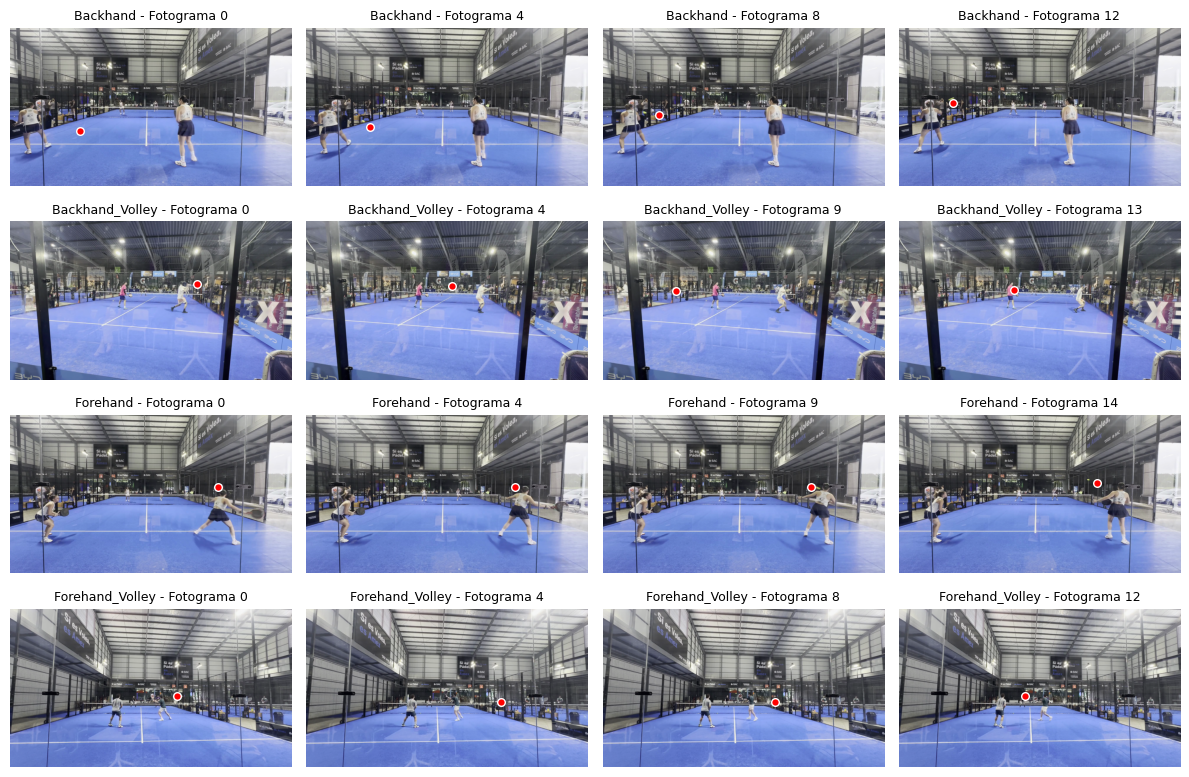

In [7]:
def visualize_tracks_grid(
    manifest: pd.DataFrame,
    num_videos: int = 4,
    frames_per_video: int = 4,
) -> None:
    """Show evenly-spaced frames from multiple videos in a grid."""
    videos_to_show = manifest.head(num_videos)
    fig, axes = plt.subplots(num_videos, frames_per_video, figsize=(frames_per_video * 3, num_videos * 2))
    
    for vid_idx, row in enumerate(videos_to_show.itertuples(index=False)):
        video_path = DATASET_ROOT / row.stroke / row.video
        payload = json.loads(Path(row.ball_json).read_text())
        centers = {int(e['frame_idx']): e['center'] for e in payload['frames'] if 'center' in e}
        
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
        cap.release()
        
        # Select evenly spaced frame indices
        total_frames = len(frames)
        frame_indices = [int(i * total_frames / frames_per_video) for i in range(frames_per_video)]
        
        for frame_idx, ax_idx in enumerate(frame_indices):
            ax = axes[vid_idx, frame_idx] if num_videos > 1 else axes[frame_idx]
            frame = frames[ax_idx]
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(rgb)
            center = centers.get(ax_idx)
            if center:
                ax.scatter(center[0], center[1], c='red', s=30, marker='o', edgecolors='white', linewidths=1)
            ax.set_title(f'{row.stroke} - Fotograma {ax_idx}', fontsize=9)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()


# Visualize 4 videos with 4 frames each (one per stroke type)
if not ball_manifest.empty:
    visualize_tracks_grid(ball_manifest, num_videos=len(ball_manifest), frames_per_video=4)

## Video Export with Overlay
Generate MP4 videos with red tracking circles overlaid on the ball.

In [9]:
def export_track_video(
    video_path: Path,
    payload: dict,
    out_path: Optional[Path] = None,
    step: int = 1,
    trail: int = 8,
) -> Path:
    """Export video with ball tracking overlay as MP4."""
    if not video_path.exists():
        raise FileNotFoundError(video_path)
    
    centers = {int(e['frame_idx']): tuple(e['center']) for e in payload['frames'] if 'center' in e}
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    out_path = Path(out_path) if out_path else VIDEO_CACHE / f"{video_path.stem}_track.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(out_path), fourcc, fps / step, (w, h))
    
    history: deque[Optional[tuple]] = deque(maxlen=trail)
    frame_idx = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        history.append(centers.get(frame_idx))
        
        if frame_idx % step == 0:
            # Draw trail with fading effect (BGR format for OpenCV)
            for depth, point in enumerate(reversed(history)):
                if point is not None:
                    radius = max(2, 6 - depth // 2)
                    cv2.circle(frame, (int(point[0]), int(point[1])), radius, 
                             (0, 0, 255), 2, cv2.LINE_AA)
            out.write(frame)
        
        frame_idx += 1
    
    cap.release()
    out.release()
    print(f'Saved to {out_path}')
    return out_path


# Generate preview videos (one per stroke type)
if not ball_manifest.empty:
    for row in ball_manifest.itertuples(index=False):
        payload = json.loads(Path(row.ball_json).read_text())
        vid_path = export_track_video(DATASET_ROOT / row.stroke / row.video, payload, step=1)

Saved to /Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-Estudio/padel-cv/artifacts/ball_tracking/videos/108cfa87_IMG_6554_Backhand_f1612-1625_track.mp4
Saved to /Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-Estudio/padel-cv/artifacts/ball_tracking/videos/4965c88d_IMG_6592_Backhand_Volley_f15597-15611_track.mp4
Saved to /Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-Estudio/padel-cv/artifacts/ball_tracking/videos/108cfa87_IMG_6554_Forehand_f1673-1687_track.mp4
Saved to /Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-Estudio/padel-cv/artifacts/ball_tracking/videos/448aeb92_IMG_6552_Forehand_Volley_f20863-20876_track.mp4
Saved to /Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-Estudio/padel-cv/artifacts/ball_tracking/videos/108cfa87_IMG_6554_Forehand_f1673-1687_track.mp4
Saved to /Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-Estudio/padel-cv/artifacts/ball_tracking/videos/448aeb92_IMG_6552_Forehand_Volley_f20863-20876_track.mp4


## Full Dataset Export
Process all videos in the dataset and compute coverage statistics.

In [10]:
# Process all videos (resume-safe with overwrite=False)
full_manifest = cache_ball_tracks(
    manifest,
    detector,
    overwrite=False,
    min_confidence=0.2,
    stride=1,
    smooth_window=7,
    max_gap=4,
)

print(f"\nCompleted: {len(full_manifest)} videos")
print(f"Coverage: {full_manifest['frames_with_centers'].sum() / full_manifest['total_frames'].sum():.1%}")
full_manifest.head(10)

Ball tracking:   0%|          | 0/188 [00:00<?, ?it/s]

a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahona_M_Backhand_f3552-3560.mp4:   0%|          | 0/11 [00:00<?, ?it…

a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahona_M_Backhand_f3670-3679.mp4:   0%|          | 0/12 [00:00<?, ?it…

a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahona_M_Backhand_f4835-4846.mp4:   0%|          | 0/15 [00:00<?, ?it…

a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahona_M_Backhand_f5671-5684.mp4:   0%|          | 0/17 [00:00<?, ?it…

...

a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahona_M_Vibora_f9005-9018.mp4:   0%|          | 0/17 [00:00<?, ?it/s…

a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahona_M_Vibora_f9367-9380.mp4:   0%|          | 0/17 [00:00<?, ?it/s…

d4e34e3e_IMG_6557_Vibora_f7828-7843.mp4:   0%|          | 0/20 [00:00<?, ?it/s]


Completed: 188 videos
Coverage: 96.3%


,stroke,video,ball_json,frames_with_centers,total_frames
0,Backhand,108cfa87_IMG_6554_Backhand_f1612-1625.mp4,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,17,17
1,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,13,13
2,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,21,21
3,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,0,17
4,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,15,15
5,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,14,14
6,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,11,11
7,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,12,12
8,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,15,15
9,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...,17,17
